In [24]:
# Cell 1: Install dependencies
!pip install ultralytics

# Cell 2: Check GPU is enabled
import torch
print(torch.cuda.is_available())  # should print True
# If False: Runtime → Change runtime type → Hardware accelerator → GPU (T4)

True


In [25]:
from google.colab import files
uploaded = files.upload()

Saving archive (8).zip to archive (8) (1).zip


In [ ]:
!unzip -o -q "archive (8).zip"

In [ ]:
import os
print("Contents of current directory:")
print(os.listdir('.'))

print("\nContents of 'val' directory:")
try:
    print(os.listdir('val'))
except FileNotFoundError:
    print("'val' directory not found.")

print("\nContents of 'test' directory:")
try:
    print(os.listdir('test'))
except FileNotFoundError:
    print("'test' directory not found.")

print("\nContents of 'train' directory:")
try:
    print(os.listdir('train'))
except FileNotFoundError:
    print("'train' directory not found.")

# Once you find the 'images' directory, you can uncomment and adjust the following lines:
# print(os.listdir('path/to/your/images'))
# For example, if images are in 'val/images':
# print(os.listdir('val/images'))

Contents of current directory:
['.config', 'LICENSE.md', 'dataset', 'meta.json', 'yolov8n.pt', 'archive (8).zip', 'runs', 'README.md', 'data.yaml', 'sample_data']

Contents of 'val' directory:
'val' directory not found.

Contents of 'test' directory:
'test' directory not found.

Contents of 'train' directory:
'train' directory not found.


In [26]:
import shutil, os

# Create base dataset directory
os.makedirs('dataset', exist_ok=True)

# Define splits based on previous directory listing
splits = ['train', 'val', 'test']

for split in splits:
    # Ensure the target split directory exists within 'dataset'
    os.makedirs(f'dataset/{split}', exist_ok=True)

    # Move images folder (e.g., 'train/img' to 'dataset/train/images')
    src_img = f'{split}/img'
    dst_img = f'dataset/{split}/images'
    if os.path.exists(src_img):
        print(f"Moving {src_img} to {dst_img}")
        shutil.move(src_img, dst_img)
    else:
        print(f"Warning: {src_img} not found. Skipping.")

    # Move labels/annotations folder (e.g., 'train/ann' to 'dataset/train/labels')
    src_ann = f'{split}/ann'
    dst_ann = f'dataset/{split}/labels'
    if os.path.exists(src_ann):
        print(f"Moving {src_ann} to {dst_ann}")
        shutil.move(src_ann, dst_ann)
    else:
        print(f"Warning: {src_ann} not found. Skipping.")

# Clean up original top-level split folders if they are empty after moving contents
for split in splits:
    if os.path.exists(split) and not os.listdir(split): # Check if directory exists and is empty
        try:
            os.rmdir(split)
            print(f"Cleaned up empty folder: {split}")
        except OSError as e:
            print(f"Error removing folder {split}: {e}")

# Verify new dataset structure
print("\n--- Dataset structure verification ---")
if os.path.exists('dataset'):
    print(f"Contents of 'dataset': {os.listdir('dataset')}")
    for split in splits:
        if os.path.exists(f'dataset/{split}'):
            print(f"  Contents of 'dataset/{split}': {os.listdir(f'dataset/{split}')}")
            if os.path.exists(f'dataset/{split}/images'):
                # Print first 5 items to avoid excessive output for large datasets
                print(f"    Contents of 'dataset/{split}/images': {os.listdir(f'dataset/{split}/images')[:5]}...")
            else:
                print(f"    'dataset/{split}/images' not found.")
            if os.path.exists(f'dataset/{split}/labels'):
                # Print first 5 items to avoid excessive output for large datasets
                print(f"    Contents of 'dataset/{split}/labels': {os.listdir(f'dataset/{split}/labels')[:5]}...")
            else:
                print(f"    'dataset/{split}/labels' not found.")
        else:
            print(f"  'dataset/{split}' not found.")
else:
    print("'dataset' directory not created.")


--- Dataset structure verification ---
Contents of 'dataset': ['val', 'train', 'test']
  Contents of 'dataset/train': ['images', 'labels', 'labels.cache']
    Contents of 'dataset/train/images': ['BloodImage_00039.jpeg', 'BloodImage_00199.jpeg', 'BloodImage_00042.jpeg', 'BloodImage_00198.jpeg', 'BloodImage_00314.jpeg']...
    Contents of 'dataset/train/labels': ['BloodImage_00308.txt', 'BloodImage_00276.txt', 'BloodImage_00356.txt', 'BloodImage_00345.txt', 'BloodImage_00079.txt']...
  Contents of 'dataset/val': ['images', 'labels', 'labels.cache']
    Contents of 'dataset/val/images': ['BloodImage_00055.jpeg', 'BloodImage_00230.jpeg', 'BloodImage_00262.jpeg', 'BloodImage_00409.jpeg', 'BloodImage_00304.jpeg']...
    Contents of 'dataset/val/labels': ['BloodImage_00140.txt', 'BloodImage_00304.txt', 'BloodImage_00064.txt', 'BloodImage_00402.txt', 'BloodImage_00274.txt']...
  Contents of 'dataset/test': ['images', 'labels']
    Contents of 'dataset/test/images': ['BloodImage_00234.jpeg', 

In [27]:
data_yaml = """
path: ./dataset

train: train/images
val: val/images
test: test/images

nc: 3

names:
  0: WBC
  1: RBC
  2: Platelets
"""

with open("data.yaml","w") as f:
    f.write(data_yaml)

print("data.yaml created")

data.yaml created


In [28]:
class_map = {
    "WBC":0,
    "RBC":1,
    "Platelets":2
}

In [29]:
def convert_json_to_yolo(json_path, img_w, img_h):

    with open(json_path) as f:
        data = json.load(f)

    labels = []

    # Iterate through 'objects' instead of 'shapes'
    for obj in data["objects"]:
        # Access classTitle and points from the object
        cls = class_map[obj["classTitle"]]
        points = obj["points"]["exterior"]

        (x1, y1) = points[0]
        (x2, y2) = points[1]

        # Normalize coordinates and calculate width/height
        xc = ((x1 + x2) / 2) / img_w
        yc = ((y1 + y2) / 2) / img_h
        w = abs(x2 - x1) / img_w
        h = abs(y2 - y1) / img_h

        labels.append(f"{cls} {xc} {yc} {w} {h}")

    return labels

In [30]:
import os

print(os.listdir("./dataset/train/labels")[:10])

['BloodImage_00308.txt', 'BloodImage_00276.txt', 'BloodImage_00356.txt', 'BloodImage_00345.txt', 'BloodImage_00079.txt', 'BloodImage_00159.txt', 'BloodImage_00283.txt', 'BloodImage_00408.txt', 'BloodImage_00215.txt', 'BloodImage_00275.txt']


In [33]:
import json

sample = "./dataset/train/labels/BloodImage_00387.jpeg.json"

with open(sample, "r") as f:
    data = json.load(f)

print(data.keys())

FileNotFoundError: [Errno 2] No such file or directory: './dataset/train/labels/BloodImage_00387.jpeg.json'

In [34]:
sample_txt_path = './dataset/train/labels/BloodImage_00364.jpeg.txt'

print(f"Content of {sample_txt_path}:")
if os.path.exists(sample_txt_path):
    with open(sample_txt_path, 'r') as f:
        content = f.read()
        print(content)
else:
    print(f"Error: {sample_txt_path} not found.")


Content of ./dataset/train/labels/BloodImage_00364.jpeg.txt:
Error: ./dataset/train/labels/BloodImage_00364.jpeg.txt not found.


In [35]:
import os

files = os.listdir("./dataset/train/labels")

print("Total JSON files:", len(files))
print(files[:20])

Total JSON files: 205
['BloodImage_00308.txt', 'BloodImage_00276.txt', 'BloodImage_00356.txt', 'BloodImage_00345.txt', 'BloodImage_00079.txt', 'BloodImage_00159.txt', 'BloodImage_00283.txt', 'BloodImage_00408.txt', 'BloodImage_00215.txt', 'BloodImage_00275.txt', 'BloodImage_00232.txt', 'BloodImage_00364.txt', 'BloodImage_00150.txt', 'BloodImage_00239.txt', 'BloodImage_00043.txt', 'BloodImage_00078.txt', 'BloodImage_00201.txt', 'BloodImage_00353.txt', 'BloodImage_00114.txt', 'BloodImage_00378.txt']


In [36]:
import os

print(os.path.exists("./dataset/train/labels/BloodImage_00364.jpeg.json"))

False


In [37]:
import os

print("Train Images:", len(os.listdir("./dataset/train/images")))
print("Train Labels:", len(os.listdir("./dataset/train/labels")))

Train Images: 205
Train Labels: 205


In [38]:
import glob
import os

txt_files = glob.glob("./dataset/train/labels/*.txt")

empty = 0

for f in txt_files:
    if os.path.getsize(f) == 0:
        empty += 1

print("Total txt files:", len(txt_files))
print("Empty txt files:", empty)

Total txt files: 205
Empty txt files: 0


In [39]:
import os
import glob
import json
import cv2

# --- Label Conversion from JSON to YOLO TXT format ---
# This code block was previously part of k8pCGNMrPqVT and is needed to generate the .txt label files.

# NOTE: `class_map` and `convert_json_to_yolo` function should be defined in earlier cells.
# Ensure `class_map` is defined, e.g., from cell SfpTq27gRE4r
# Ensure `convert_json_to_yolo` is defined, e.g., from cell VExCPDIxRHIg

print("\nStarting JSON to YOLO label conversion...")
base_dataset_path = './dataset'
splits = ['train', 'val', 'test']

for split in splits:
    label_json_dir = os.path.join(base_dataset_path, split, 'labels') # Directory containing original JSONs
    label_txt_dir = os.path.join(base_dataset_path, split, 'labels') # Directory for new TXT files
    image_dir = os.path.join(base_dataset_path, split, 'images')
    os.makedirs(label_txt_dir, exist_ok=True) # Ensure the labels directory exists

    # Get all .json files in the labels directory
    json_files = [f for f in os.listdir(label_json_dir) if f.endswith('.json')]

    for json_filename in json_files:
        json_filepath = os.path.join(label_json_dir, json_filename)
        txt_filename = json_filename.replace('.json', '.txt') # Correctly generate .txt filename
        txt_filepath = os.path.join(label_txt_dir, txt_filename)

        # Try to infer image dimensions from the JSON file itself or by reading the image
        image_width, image_height = None, None # Reset for each file
        try:
            with open(json_filepath, 'r') as f:
                json_content = json.load(f)
                if 'imageWidth' in json_content and 'imageHeight' in json_content:
                    image_width = json_content['imageWidth']
                    image_height = json_content['imageHeight']
                else:
                    # Fallback to reading image file if dimensions are not in JSON
                    img_filename_base = json_filename.split('.json')[0]
                    img_filename = f"{img_filename_base}"
                    img_filepath = os.path.join(image_dir, img_filename)
                    if os.path.exists(img_filepath):
                        img = cv2.imread(img_filepath)
                        if img is not None:
                            image_height, image_width, _ = img.shape
                        else:
                            print(f"Warning: Could not read image {img_filepath}. Skipping {json_filepath}")
                            continue
                    else:
                        print(f"Warning: Image {img_filepath} not found for label {json_filepath}. Skipping.")
                        continue
        except Exception as e:
            print(f"Error processing {json_filepath} for dimensions: {e}. Skipping.")
            continue

        if image_width is None or image_height is None:
            print(f"Error: Could not determine image dimensions for {json_filepath}. Skipping.")
            continue

        yolo_labels = convert_json_to_yolo(json_filepath, image_width, image_height)

        if not yolo_labels:
            print(f"DEBUG: No YOLO labels generated for {json_filename}. This will result in an empty .txt file.")

        with open(txt_filepath, 'w') as f:
            for label_line in yolo_labels:
                f.write(label_line + '\n')
        print(f"DEBUG: Generated {len(yolo_labels)} YOLO labels for {json_filename}. Written to {txt_filepath}")
        if yolo_labels:
            print(f"DEBUG: Sample YOLO label for {json_filename}: {yolo_labels[0]}")

        # Remove the original .json file after conversion
        os.remove(json_filepath)

print("JSON to YOLO label conversion complete.")

# Verification step: Check created .txt files and remaining .json files
print("\nVerifying label directories after conversion:")
for split in splits:
    label_dir = os.path.join(base_dataset_path, split, 'labels')
    txt_files_count = len([f for f in os.listdir(label_dir) if f.endswith('.txt')])
    json_files_count = len([f for f in os.listdir(label_dir) if f.endswith('.json')])
    print(f"  {split} labels: {txt_files_count} .txt files, {json_files_count} .json files remaining.")


Starting JSON to YOLO label conversion...
JSON to YOLO label conversion complete.

Verifying label directories after conversion:
  train labels: 205 .txt files, 0 .json files remaining.
  val labels: 87 .txt files, 0 .json files remaining.
  test labels: 72 .txt files, 0 .json files remaining.


In [40]:
import os

labels = os.listdir("./dataset/train/labels")

for i in labels[:20]:
    print(i)

BloodImage_00308.txt
BloodImage_00276.txt
BloodImage_00356.txt
BloodImage_00345.txt
BloodImage_00079.txt
BloodImage_00159.txt
BloodImage_00283.txt
BloodImage_00408.txt
BloodImage_00215.txt
BloodImage_00275.txt
BloodImage_00232.txt
BloodImage_00364.txt
BloodImage_00150.txt
BloodImage_00239.txt
BloodImage_00043.txt
BloodImage_00078.txt
BloodImage_00201.txt
BloodImage_00353.txt
BloodImage_00114.txt
BloodImage_00378.txt


In [41]:
import os

image = "./dataset/train/images/BloodImage_00364.jpeg"
label = "./dataset/train/labels/BloodImage_00364.jpeg.txt"

print("Image exists:", os.path.exists(image))
print("Label exists:", os.path.exists(label))

Image exists: True
Label exists: False


In [42]:
import os
import glob

label_dir = "./dataset/train/labels"

for file in glob.glob(label_dir + "/*.jpeg.txt"):
    new_name = file.replace(".jpeg.txt", ".txt")
    os.rename(file, new_name)

print("✅ Train labels renamed!")

✅ Train labels renamed!


In [43]:
for split in ["val", "test"]:
    label_dir = f"./dataset/{split}/labels"

    for file in glob.glob(label_dir + "/*.jpeg.txt"):
        new_name = file.replace(".jpeg.txt", ".txt")
        os.rename(file, new_name)

print("✅ All labels renamed!")

✅ All labels renamed!


In [44]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [45]:
from ultralytics import YOLO

# Load pretrained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data="data.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device="cpu",          # Use "0" if you have an NVIDIA GPU
    workers=2,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    patience=20,
    cache=True,
    pretrained=True,
    project="Blood_Cell_Detection",

    name="YOLOv8n_BCCD",
    exist_ok=True,
    verbose=True
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_BCCD, nbs=64, nms=False, opset=None, opt

In [46]:
from ultralytics import YOLO

# Trained model path (best.pt) - path-a unga setup ku maathikonga
model = YOLO("/content/runs/detect/Blood_Cell_Detection/YOLOv8n_BCCD/weights/best.pt")

# Validation run pannurom (data.yaml path correct ah kudukanum)
metrics = model.val(data="data.yaml")

print("\n===== ACCURACY METRICS =====")
print(f"Precision      : {metrics.box.mp:.3f}")
print(f"Recall         : {metrics.box.mr:.3f}")
print(f"mAP50          : {metrics.box.map50:.3f}")
print(f"mAP50-95       : {metrics.box.map:.3f}")

print("\n===== CLASS-WISE mAP50 =====")
class_names = model.names
for i, ap50 in enumerate(metrics.box.ap50):
    print(f"{class_names[i]:<12}: {ap50:.3f}")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 707.1±206.0 MB/s, size: 20.4 KB)
val: Scanning /content/dataset/val/labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 21.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.3s
                   all         87       1138      0.848      0.905      0.914      0.632
                   WBC         86         87      0.981          1       0.99      0.808
                   RBC         83        968      0.768      0.837       0.88      0.626
             Platelets         45         83      0.793      0.877      0.871      0.461
Speed: 3.6ms preprocess, 5.3ms inference, 0.0ms loss, 9.1ms postprocess per image
Results saved to /content/runs/detect/val

===== ACCURACY METRI

Saving blood.webp to blood.webp

image 1/1 /content/blood.webp: 480x640 1 WBC, 93 RBCs, 1 Platelets, 6.2ms
Speed: 2.8ms preprocess, 6.2ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict

===== DETECTED CELLS =====
RBC - confidence: 0.97
RBC - confidence: 0.95
RBC - confidence: 0.95
RBC - confidence: 0.95
RBC - confidence: 0.94
RBC - confidence: 0.94
RBC - confidence: 0.93
RBC - confidence: 0.93
RBC - confidence: 0.92
RBC - confidence: 0.92
RBC - confidence: 0.91
RBC - confidence: 0.91
RBC - confidence: 0.91
RBC - confidence: 0.91
RBC - confidence: 0.91
RBC - confidence: 0.90
RBC - confidence: 0.90
RBC - confidence: 0.90
RBC - confidence: 0.89
RBC - confidence: 0.89
RBC - confidence: 0.89
RBC - confidence: 0.88
RBC - confidence: 0.86
RBC - confidence: 0.84
RBC - confidence: 0.84
RBC - confidence: 0.84
RBC - confidence: 0.83
RBC - confidence: 0.83
RBC - confidence: 0.83
RBC - confidence: 0.82
RBC - confidence: 0.82
RBC - conf

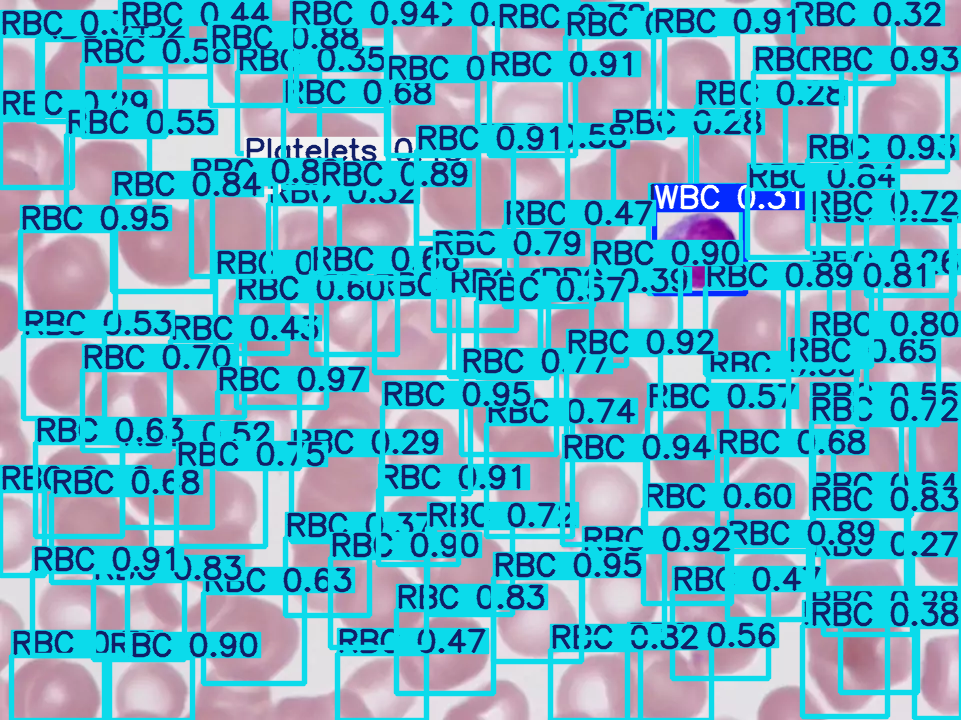


Annotated image saved at: /content/runs/detect/predict


In [47]:
from ultralytics import YOLO
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow

# ---- 1. Trained model load pannurom ----
model = YOLO("/content/runs/detect/Blood_Cell_Detection/YOLOv8n_BCCD/weights/best.pt")

# ---- 2. Image upload pannunga ----
uploaded = files.upload()   # upload button varum, image select pannunga
image_path = list(uploaded.keys())[0]   # uploaded image name eduthukom

# ---- 3. Prediction pannurom ----
results = model.predict(source=image_path, conf=0.25, save=True)

# ---- 4. Detected classes and counts print pannurom ----
result = results[0]
class_names = model.names

print("\n===== DETECTED CELLS =====")
counts = {}
for box in result.boxes:
    cls_id = int(box.cls[0])
    cls_name = class_names[cls_id]
    conf = float(box.conf[0])
    counts[cls_name] = counts.get(cls_name, 0) + 1
    print(f"{cls_name} - confidence: {conf:.2f}")

print("\n===== TOTAL COUNT =====")
for cls_name, count in counts.items():
    print(f"{cls_name}: {count}")

# ---- 5. Detected image show pannurom (bounding boxes udan) ----
annotated_img = result.plot()   # bounding box + label draw pannina image
cv2_imshow(annotated_img)

# ---- 6. Output image save aagi irukura path ----
print(f"\nAnnotated image saved at: {result.save_dir}")
